In [1]:
import pandas as pd
import os

# See what files are available
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_specialities.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/employee_counts.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/benefits.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/salaries.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows of description column:")
print(df['description'].head(3))

Shape: (123849, 31)

Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

First few rows of description column:
0    Job descriptionA leading real estate firm in N...
1    At Aspen Therapy and Wellness , we are committ...
2    The National Exemplar is accepting application...
Name: description, dtype: object


In [3]:
# Keep only what we need
df_clean = df[['job_id', 'title', 'company_name', 'location', 'description']].copy()

# Drop rows with missing descriptions
df_clean = df_clean.dropna(subset=['description'])

print(f"Clean dataset shape: {df_clean.shape}")
print(f"\nSample job title: {df_clean['title'].iloc[0]}")
print(f"\nSample description (first 300 chars):")
print(df_clean['description'].iloc[0][:300])

Clean dataset shape: (123842, 5)

Sample job title: Marketing Coordinator

Sample description (first 300 chars):
Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambitious members of the sales team and our dynamic executive team on a daily basis. This is an opportuni


In [4]:
# Bias lexicon based on Gaucher, Friesen & Kay (2011) research
# and extended with age-bias and exclusionary language

masculine_coded = [
    'competitive', 'dominant', 'aggressive', 'ambitious', 'assertive',
    'confident', 'decisive', 'determined', 'independent', 'leader',
    'ninja', 'rockstar', 'superhero', 'guru', 'wizard', 'hacker',
    'hustle', 'crushing it', 'kill it', 'dominate', 'champion',
    'outperform', 'driven', 'fearless', 'bold', 'strong'
]

feminine_coded = [
    'collaborative', 'cooperative', 'supportive', 'nurturing', 'empathetic',
    'compassionate', 'interpersonal', 'warm', 'caring', 'inclusive',
    'together', 'share', 'honest', 'trust', 'understanding', 'sensitive'
]

age_biased = [
    'digital native', 'young', 'energetic', 'recent graduate', 'fresh graduate',
    'new graduate', 'youthful', 'up and coming', 'junior only',
    'overqualified', 'seasoned only', 'years of experience'
]

exclusionary = [
    'beer fridays', 'ping pong', 'frat', 'fraternity', 'boys club',
    'crazy', 'insane', 'manpower', 'mankind', 'he or she',
    'native english', 'perfect english', 'no gaps', 'must be local'
]

print(f"Masculine coded words: {len(masculine_coded)}")
print(f"Feminine coded words: {len(feminine_coded)}")
print(f"Age biased words: {len(age_biased)}")
print(f"Exclusionary words: {len(exclusionary)}")
print("\nLexicon ready!")

Masculine coded words: 26
Feminine coded words: 16
Age biased words: 12
Exclusionary words: 14

Lexicon ready!


In [5]:
import re

def analyse_bias(text):
    if not isinstance(text, str):
        return None
    
    text_lower = text.lower()
    
    # Find matches for each category
    found_masculine = [w for w in masculine_coded if w in text_lower]
    found_feminine = [w for w in feminine_coded if w in text_lower]
    found_age = [w for w in age_biased if w in text_lower]
    found_exclusionary = [w for w in exclusionary if w in text_lower]
    
    # Calculate bias score (0-100)
    total_flags = (len(found_masculine) * 2 + 
                   len(found_feminine) * 2 + 
                   len(found_age) * 3 +      # age bias weighted higher
                   len(found_exclusionary) * 3)  # exclusionary weighted higher
    
    bias_score = min(100, total_flags * 5)
    
    # Determine overall bias type
    if len(found_masculine) > len(found_feminine):
        bias_type = "Male-skewed"
    elif len(found_feminine) > len(found_masculine):
        bias_type = "Female-skewed"
    else:
        bias_type = "Neutral"
    
    return {
        'bias_score': bias_score,
        'bias_type': bias_type,
        'masculine_flags': found_masculine,
        'feminine_flags': found_feminine,
        'age_flags': found_age,
        'exclusionary_flags': found_exclusionary,
        'total_flags': len(found_masculine) + len(found_feminine) + 
                       len(found_age) + len(found_exclusionary)
    }

# Test on first job posting
result = analyse_bias(df_clean['description'].iloc[0])
print(f"Job: {df_clean['title'].iloc[0]}")
print(f"Bias Score: {result['bias_score']}/100")
print(f"Bias Type: {result['bias_type']}")
print(f"Masculine flags: {result['masculine_flags']}")
print(f"Feminine flags: {result['feminine_flags']}")
print(f"Age flags: {result['age_flags']}")
print(f"Exclusionary flags: {result['exclusionary_flags']}")

Job: Marketing Coordinator
Bias Score: 10/100
Bias Type: Male-skewed
Masculine flags: ['ambitious']
Feminine flags: []
Age flags: []
Exclusionary flags: []


In [6]:
print("Analysing all job postings... this may take a minute!")

# Apply analyser to every posting
results = df_clean['description'].apply(analyse_bias)

# Extract results into columns
df_clean['bias_score'] = results.apply(lambda x: x['bias_score'] if x else 0)
df_clean['bias_type'] = results.apply(lambda x: x['bias_type'] if x else 'Unknown')
df_clean['masculine_flags'] = results.apply(lambda x: len(x['masculine_flags']) if x else 0)
df_clean['feminine_flags'] = results.apply(lambda x: len(x['feminine_flags']) if x else 0)
df_clean['age_flags'] = results.apply(lambda x: len(x['age_flags']) if x else 0)
df_clean['exclusionary_flags'] = results.apply(lambda x: len(x['exclusionary_flags']) if x else 0)
df_clean['total_flags'] = results.apply(lambda x: x['total_flags'] if x else 0)

print("Done!")
print(f"\nBias type distribution:")
print(df_clean['bias_type'].value_counts())

Analysing all job postings... this may take a minute!
Done!

Bias type distribution:
bias_type
Male-skewed      56936
Neutral          35989
Female-skewed    30917
Name: count, dtype: int64


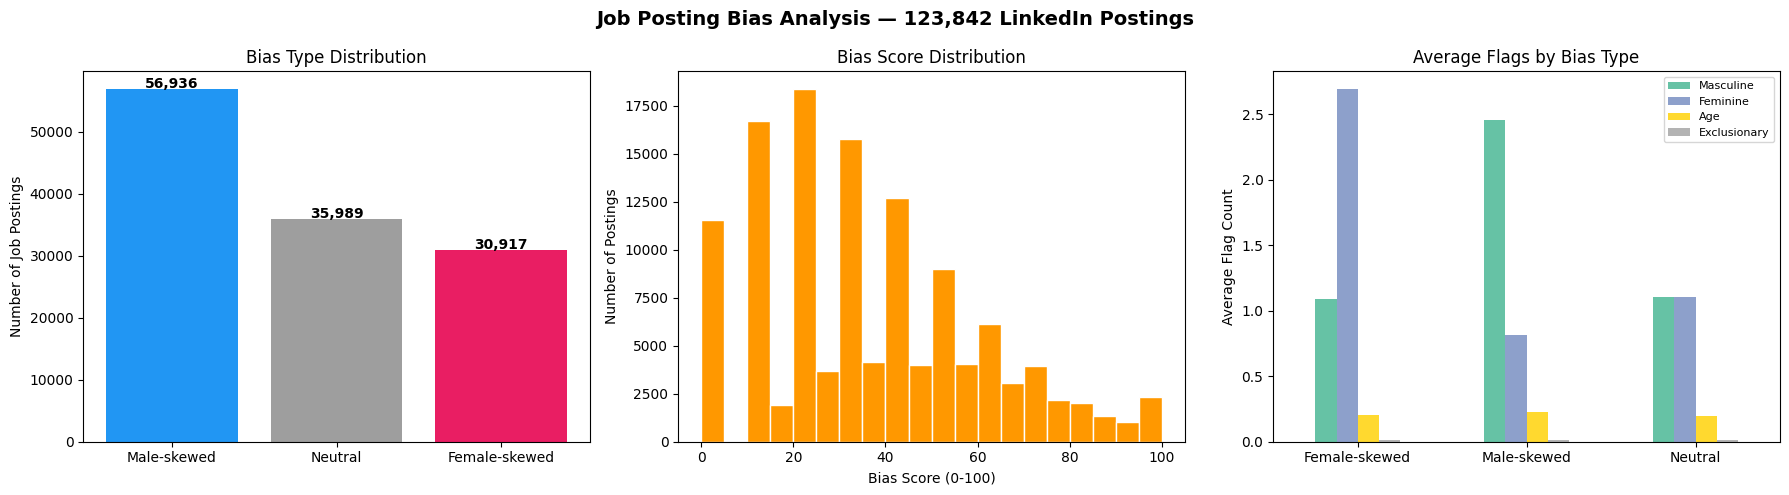

Saved!


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Job Posting Bias Analysis — 123,842 LinkedIn Postings', 
             fontsize=14, fontweight='bold')

# 1. Bias type distribution
colors = ['#2196F3', '#9E9E9E', '#E91E63']
counts = df_clean['bias_type'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Bias Type Distribution')
axes[0].set_ylabel('Number of Job Postings')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# 2. Bias score distribution
axes[1].hist(df_clean['bias_score'], bins=20, color='#FF9800', edgecolor='white')
axes[1].set_title('Bias Score Distribution')
axes[1].set_xlabel('Bias Score (0-100)')
axes[1].set_ylabel('Number of Postings')

# 3. Average flags by bias type
flag_cols = ['masculine_flags', 'feminine_flags', 'age_flags', 'exclusionary_flags']
avg_flags = df_clean.groupby('bias_type')[flag_cols].mean()
avg_flags.plot(kind='bar', ax=axes[2], colormap='Set2')
axes[2].set_title('Average Flags by Bias Type')
axes[2].set_xlabel('')
axes[2].set_ylabel('Average Flag Count')
axes[2].legend(['Masculine', 'Feminine', 'Age', 'Exclusionary'], 
               loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('bias_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")

In [8]:
# Most male-skewed job titles
print("TOP 10 MOST MALE-SKEWED JOB TITLES (avg bias score):")
male_skewed = df_clean[df_clean['bias_type'] == 'Male-skewed']
top_male = male_skewed.groupby('title')['bias_score'].mean().sort_values(ascending=False).head(10)
print(top_male.to_string())

print("\nTOP 10 MOST FEMALE-SKEWED JOB TITLES (avg bias score):")
female_skewed = df_clean[df_clean['bias_type'] == 'Female-skewed']
top_female = female_skewed.groupby('title')['bias_score'].mean().sort_values(ascending=False).head(10)
print(top_female.to_string())

TOP 10 MOST MALE-SKEWED JOB TITLES (avg bias score):
title
Engineer (Cloud Big Data / Scala / Spark) - Associate     100.0
Nurse Shift Manager Emergency                             100.0
Energy Storage Independent Engineering Project Manager    100.0
RN Case Manager                                           100.0
Additive Manufacturing Engineer                           100.0
Employee Benefits Administrator - ESOP                    100.0
QA Engineer II                                            100.0
Sr. Associate, Product Management                         100.0
Sr. Catheter Engineer                                     100.0
Manager, Asset Protection                                 100.0

TOP 10 MOST FEMALE-SKEWED JOB TITLES (avg bias score):
title
Aquatics Director                                                                 100.0
Area Service Leader - Anchorage AK                                                100.0
RN-Registered Nurse RN- Neuro ICU- FT Day                      

In [9]:
def bias_report(job_text, job_title="Job Posting"):
    result = analyse_bias(job_text)
    
    print(f"{'='*60}")
    print(f"BIAS ANALYSIS REPORT: {job_title}")
    print(f"{'='*60}")
    print(f"Bias Score:  {result['bias_score']}/100")
    print(f"Bias Type:   {result['bias_type']}")
    print(f"Total Flags: {result['total_flags']}")
    print(f"{'-'*60}")
    
    if result['masculine_flags']:
        print(f"⚡ Masculine-coded words: {', '.join(result['masculine_flags'])}")
    if result['feminine_flags']:
        print(f"🌸 Feminine-coded words:  {', '.join(result['feminine_flags'])}")
    if result['age_flags']:
        print(f"⏰ Age-biased language:   {', '.join(result['age_flags'])}")
    if result['exclusionary_flags']:
        print(f"🚫 Exclusionary language: {', '.join(result['exclusionary_flags'])}")
    
    print(f"{'-'*60}")
    if result['bias_score'] == 0:
        print("✅ This posting appears bias-free!")
    elif result['bias_score'] < 20:
        print("🟡 Low bias — minor improvements recommended.")
    elif result['bias_score'] < 50:
        print("🟠 Moderate bias — consider revising flagged words.")
    else:
        print("🔴 High bias — significant revision recommended.")
    print(f"{'='*60}")

# Test it on a made-up biased job posting
test_job = """
We are looking for a rockstar ninja developer who is 
aggressive, competitive and driven to dominate the market.
Must be a digital native who can hustle hard and crush it.
We offer beer fridays and a fun fraternity-like culture.
Recent graduates preferred.
"""

bias_report(test_job, "Software Engineer (Biased Example)")

BIAS ANALYSIS REPORT: Software Engineer (Biased Example)
Bias Score:  100/100
Bias Type:   Male-skewed
Total Flags: 12
------------------------------------------------------------
⚡ Masculine-coded words: competitive, aggressive, ninja, rockstar, hustle, dominate, driven
⏰ Age-biased language:   digital native, recent graduate
🚫 Exclusionary language: beer fridays, frat, fraternity
------------------------------------------------------------
🔴 High bias — significant revision recommended.


In [10]:
# Test on a real Data Scientist job posting
test_real = """
We are looking for a passionate and collaborative Data Scientist 
to join our inclusive and supportive team. You will work closely 
with cross-functional teams to deliver data-driven insights.
We value empathy, trust, and honest communication.
The ideal candidate is ambitious, confident and decisive,
with a strong desire to lead and dominate in their field.
Must have a degree and 5+ years experience.
"""

bias_report(test_real, "Data Scientist (Mixed Example)")

BIAS ANALYSIS REPORT: Data Scientist (Mixed Example)
Bias Score:  100/100
Bias Type:   Male-skewed
Total Flags: 11
------------------------------------------------------------
⚡ Masculine-coded words: ambitious, confident, decisive, dominate, driven, strong
🌸 Feminine-coded words:  collaborative, supportive, inclusive, honest, trust
------------------------------------------------------------
🔴 High bias — significant revision recommended.


In [11]:
# Merge with industry data
industries = pd.read_csv('/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_industries.csv')
industry_names = pd.read_csv('/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/industries.csv')

# Merge industries with names
industries_merged = industries.merge(industry_names, on='industry_id', how='left')

# Merge with our bias results
df_industry = df_clean.merge(industries_merged, on='job_id', how='left')

# Average bias score by industry
industry_bias = df_industry.groupby('industry_name')['bias_score'].agg(['mean', 'count'])
industry_bias = industry_bias[industry_bias['count'] > 100]  # only industries with 100+ postings
industry_bias = industry_bias.sort_values('mean', ascending=False)

print("TOP 10 MOST BIASED INDUSTRIES:")
print(industry_bias.head(10).to_string())
print("\nTOP 10 LEAST BIASED INDUSTRIES:")
print(industry_bias.tail(10).to_string())

TOP 10 MOST BIASED INDUSTRIES:
                                                    mean  count
industry_name                                                  
Public Safety                                  58.814714    367
Public Relations and Communications Services   51.066066    333
Venture Capital and Private Equity Principals  49.520295    271
E-Learning Providers                           49.370079    254
Media Production                               48.886010    193
Technology, Information and Internet           47.322023   1503
Investment Management                          46.371882    882
Market Research                                45.648148    108
Personal Care Product Manufacturing            44.914384    292
Internet Marketplace Platforms                 43.829787    188

TOP 10 LEAST BIASED INDUSTRIES:
                                         mean  count
industry_name                                       
Facilities Services                 27.139384    617
Warehousi

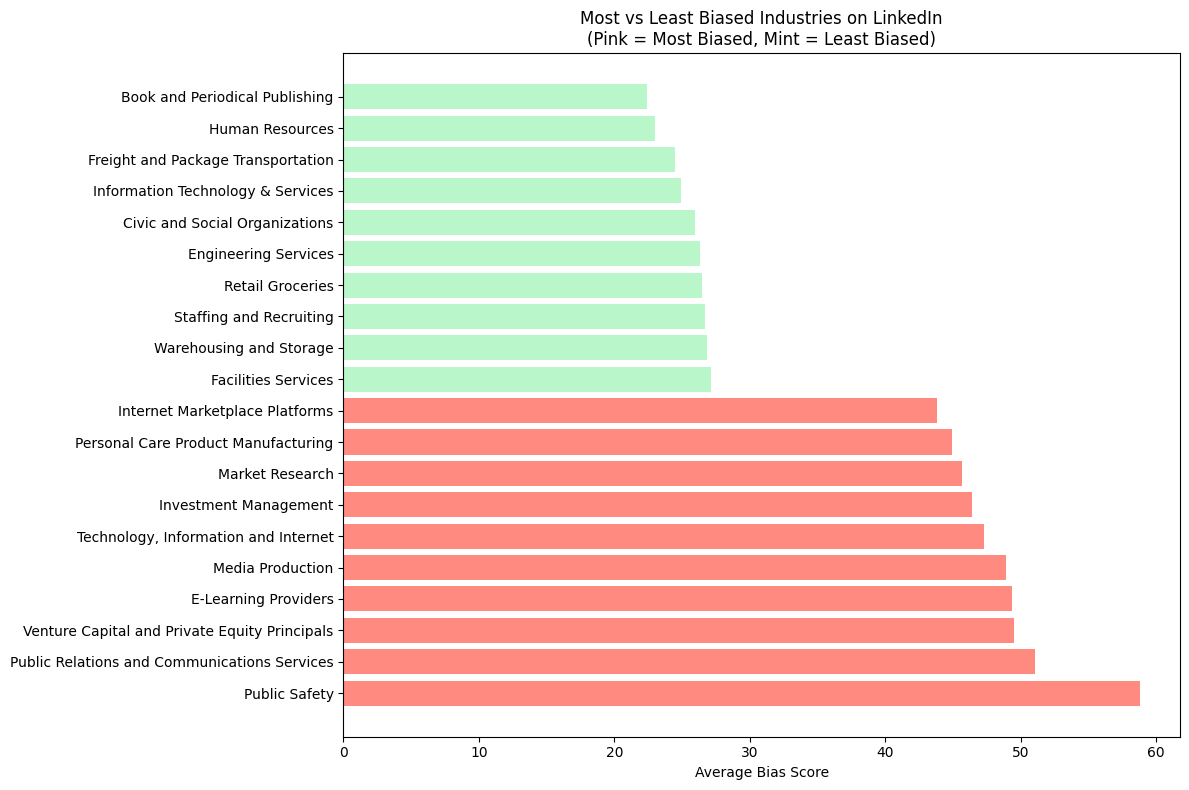

Saved!


In [13]:
plt.figure(figsize=(12, 8))
top_bottom = pd.concat([industry_bias.head(10), industry_bias.tail(10)])
colors = ['#FF8A80']*10 + ['#B9F6CA']*10
plt.barh(top_bottom.index, top_bottom['mean'], color=colors)
plt.xlabel('Average Bias Score')
plt.title('Most vs Least Biased Industries on LinkedIn\n(Pink = Most Biased, Mint = Least Biased)')
plt.tight_layout()
plt.savefig('industry_bias.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved!")